In [1]:
import pandas as pd

job_data = {
    'job_id': [101, 102, 103, 104, 105, 106],
    'job_title': [
        'Data Analyst',
        'Data Engineer',
        'Python Developer',
        'Business Analyst',
        'Data Scientist',
        'SQL Developer'
    ],
    'company_name': [
        'Amazon',
        'Netflix',
        'Tesla',
        'Amazon',
        'IBM',
        'Spotify'
    ],
    'job_location': [
        'Seattle, WA',
        'Los Gatos, CA',
        'Austin, TX',
        'New York, NY',
        'Boston, MA',
        'New York, NY'
    ]
}

company_data = {
    'company_name': [
        'Amazon',
        'Netflix',
        'Tesla',
        'IBM',
        'Adobe',
        'Intel'
    ],
    'industry': [
        'Technology',
        'Entertainment',
        'Automotive',
        'Technology',
        'Software',
        'Semiconductors'
    ],
    'company_size': [
        '1,500,000+',
        '14,000+',
        '140,000+',
        '280,000+',
        '30,000+',
        '120,000+'
    ]
}

df_jobs = pd.DataFrame(job_data)
df_companies = pd.DataFrame(company_data)

In [2]:
df_jobs

,job_id,job_title,company_name,job_location
0,101,Data Analyst,Amazon,"Seattle, WA"
1,102,Data Engineer,Netflix,"Los Gatos, CA"
2,103,Python Developer,Tesla,"Austin, TX"
3,104,Business Analyst,Amazon,"New York, NY"
4,105,Data Scientist,IBM,"Boston, MA"
5,106,SQL Developer,Spotify,"New York, NY"


In [3]:
df_companies

,company_name,industry,company_size
0,Amazon,Technology,"1,500,000+"
1,Netflix,Entertainment,"14,000+"
2,Tesla,Automotive,"140,000+"
3,IBM,Technology,"280,000+"
4,Adobe,Software,"30,000+"
5,Intel,Semiconductors,"120,000+"


Merging

In [5]:
df_jobs.merge(df_companies, how='left', on='company_name')

,job_id,job_title,company_name,job_location,industry,company_size
0,101,Data Analyst,Amazon,"Seattle, WA",Technology,"1,500,000+"
1,102,Data Engineer,Netflix,"Los Gatos, CA",Entertainment,"14,000+"
2,103,Python Developer,Tesla,"Austin, TX",Automotive,"140,000+"
3,104,Business Analyst,Amazon,"New York, NY",Technology,"1,500,000+"
4,105,Data Scientist,IBM,"Boston, MA",Technology,"280,000+"
5,106,SQL Developer,Spotify,"New York, NY",NaN,NaN


In [21]:

import pandas as pd
import numpy as np
from datasets import load_dataset
import matplotlib.pyplot as plt

# loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'], errors='coerce')
df['job_posted_month'] = df['job_posted_date'].dt.month_name()
df_usa = df[df['job_country'] == 'United States'].copy()
df_usa_pivot = df_usa.pivot_table(index='job_posted_month', columns='job_title_short', values='salary_year_avg', aggfunc='size')


df_US_software_pivot = pd.read_csv('https://lukeb.co/software_csv')

In [22]:
df_usa_pivot
# the index colun is job_posted_month

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
April,565,40,6049,2801,4867,51,1025,781,991,112
August,903,39,6634,3269,6318,68,1186,903,1515,194
December,648,40,3979,2641,3472,119,601,689,752,212
February,447,24,6124,3060,4956,56,1258,878,1127,90
January,527,36,8494,2655,6915,60,1544,773,1552,114
July,581,39,5201,2570,4876,65,883,747,1095,153
June,446,32,5683,2893,4645,48,1009,812,1033,93
March,438,19,6218,3183,4779,59,1114,829,1150,115
May,279,20,4993,2976,4377,49,839,746,914,90


In [ ]:
#changing index column to match df_usa_pivot data set
if (
    df_US_software_pivot.index.name != 'job_posted_month'
    and 'job_posted_month' in df_US_software_pivot.columns
):
    df_US_software_pivot = df_US_software_pivot.set_index('job_posted_month')
    
df_US_software_pivot

,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer
job_posted_month,,,,
January,13619,9827,5108,4348
February,11456,9116,7298,4284
March,11102,8178,5814,4159
April,14037,9209,7232,4220
May,12126,8864,6718,4980
June,12003,8065,5902,4781
July,11914,8061,6839,4344
August,11571,8191,7413,4104
September,14016,8447,6139,4094


<Axes: xlabel='job_posted_month'>

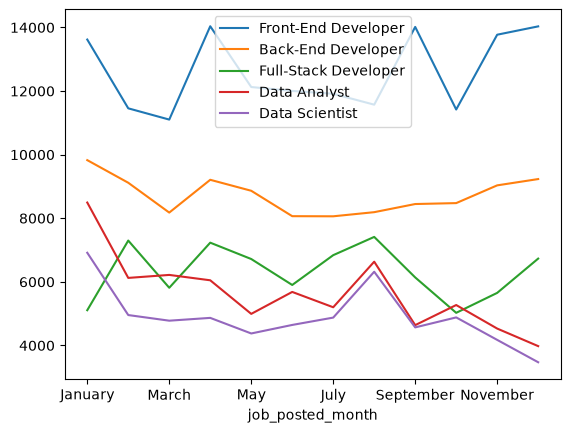

In [40]:
df_us_merged = df_usa_pivot.merge(df_US_software_pivot, how='inner', on='job_posted_month')
top5 = (df_us_merged.sum().sort_values(ascending=False).head(5).index.tolist())

df_us_merged = df_us_merged.reindex(df_US_software_pivot.index.tolist())
df_us_merged[top5].plot(kind='line')